Number of unique firms (registered_numbers) in t_panel after filtering: 148,442


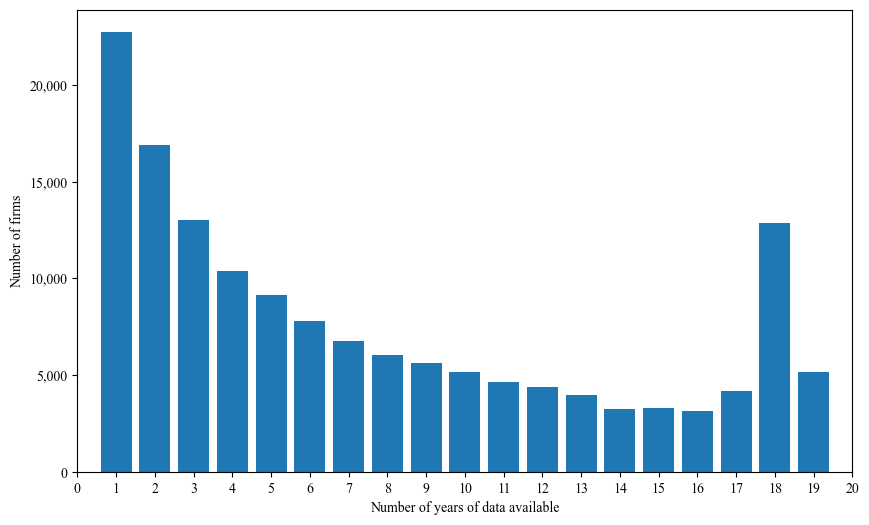

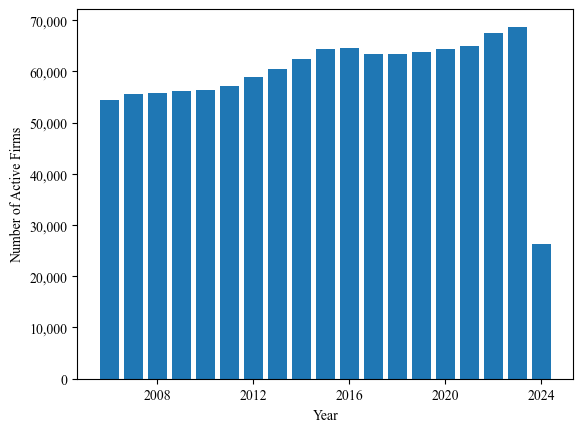

In [20]:
import ibis
from ibis import _
from utils.f_0_dirs import get_data_dirs
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman']

table_name = "working_yearly"

dirs = get_data_dirs(segment="descriptives")
con = ibis.duckdb.connect(dirs.db_path, read_only=True)
t_panel = con.table(table_name)

# How many unique registered_numbers are left after filtering?
unique_registered_numbers = t_panel['registered_number'].nunique().execute()
print(f"Number of unique firms (registered_numbers) in t_panel after filtering: {unique_registered_numbers:,}")

# Group the rows by registered_numbers. What is the distribution of the number of rows per registered_number?
# Sum the number of firms which have 1 row, 2 rows, 3 rows, etc. to get the distribution of years for each firm.

# Step 1: Count how many rows (years) exist for each firm
t_i_aggregated = (
    t_panel
    .distinct(on=["registered_number", "year"])
    .group_by("registered_number")
    .aggregate(year_count=_.count())
)

# Step 2: Group by the year_count to see how many firms have exactly 1 year, 2 years, etc.
df_years_avail = (
    t_i_aggregated.group_by("year_count")
    .aggregate(number_of_firms=_.count())
    .order_by("year_count")
    .execute()
)
plt.figure(figsize=(10, 6))
plt.bar(df_years_avail["year_count"], df_years_avail["number_of_firms"])
plt.xlim(0, 20)
plt.xticks(range(0, 21))
plt.xlabel("Number of years of data available")
plt.ylabel("Number of firms")
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.savefig(dirs.output_dir / "fig_panel_years_avail.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Group the rows by year. What is the distribution of the number of rows per year?
t_years_aggregated = (
    t_panel
    .group_by("year")
    .aggregate(number_of_rows=_.count())
    .filter(_.number_of_rows > 0)
    .order_by("year")
)
df_years_active = t_years_aggregated.execute()
plt.bar(df_years_active["year"], df_years_active["number_of_rows"])
plt.xlabel("Year")
plt.ylabel("Number of Active Firms")
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_locator(ticker.MultipleLocator(4))
plt.savefig(dirs.output_dir / "fig_panel_obvs_by_year.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()